### import and path

In [11]:
import socket
import sys
import pickle
import os
import time
from pprint import pprint

home_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

sys.path.append(home_dir)
root_dir = os.path.join(home_dir,'output_urban_planning/')
#root_dir = '/home/lxh/dev/DRL-urban-planning/output_urban_planning/'

### demo

In [9]:
from urban_planning.envs import CityEnv
from urban_planning.envs import city_config
from urban_planning.utils.config import Config

In [15]:
id = 'grid3_concept'
seed = 111
temp = False
cfg = Config(id, seed, temp, root_dir)
env = CityEnv(cfg)

Carbon emissions:
{4: 248, 8: 345.9, 5: 193, 6: 906, 7: 0, 9: 321, 10: 20, 11: 18, 12: 20}


In [17]:
init_plan_path = os.path.join(home_dir, 'urban_planning/cfg/test_data/synthetic/init_plan_grid3_concept.pickle')
d= pickle.load(open(init_plan_path, 'rb'))
#d['gdf'].to_file('init_grid2.geojson', driver='GeoJSON')

In [18]:
print(d['concept'])

[{'distance': 200, 'geometry': <shapely.geometry.point.Point object at 0x7f8ba0621820>, 'land_use': [5, 6], 'type': 'center'}, {'distance': 50, 'geometry': <shapely.geometry.linestring.LineString object at 0x7f8ba0621700>, 'land_use': [12], 'type': 'axis'}, {'distance': 50, 'geometry': <shapely.geometry.linestring.LineString object at 0x7f8ba09b2850>, 'land_use': [7, 8], 'type': 'axis'}]


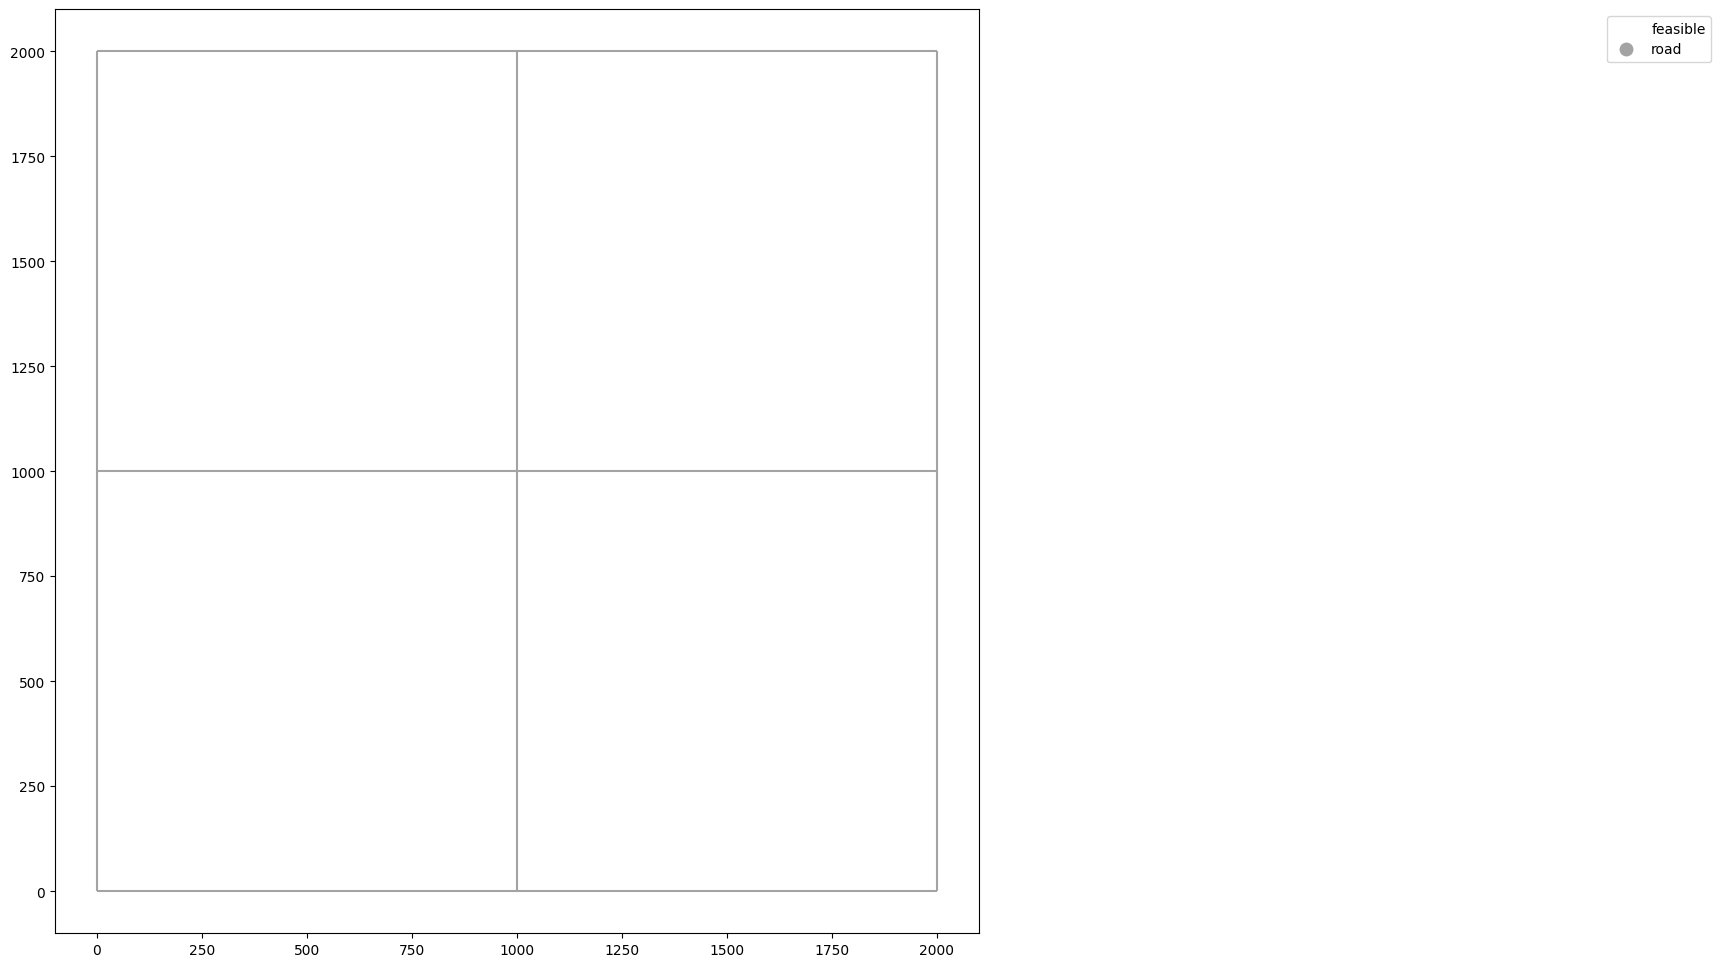

In [19]:
env.load_plan(d['gdf'])
env.visualize()

In [40]:
model_path = os.path.join(root_dir, id, str(seed), 'models', 'best.p')
d = pickle.load(open(model_path, 'rb'))
#print(d['best_plans'][0])
gdf = d['best_plans'][0]['gdf']
#gdf.plot()

In [54]:
rect_gdf=gdf[gdf['type'].isin(city_config.BLOCK_LAND_TYPE)& (gdf['rect']==1)]
abnormal_rect = (rect_gdf['sc'] - 1).sum()
abnormal_rect

-6.884021079602402

In [41]:
gdf[(gdf['type']==12) & (gdf['rect']<1)] 

,id,type,existence,geometry,rect,eqi,sc
531,NaN,12,True,"POLYGON ((1500.000 1800.000, 1700.000 1800.000...",0.84,0.916515,0.84


### load plan and score

In [42]:
env.load_plan(gdf)
env.score_plan()

reward: 1.8880935731248
{   'road_network': 0.6737654320987655,
    'life_circle': 0.36406350438398905,
    'greenness': 0.5164009071158091,
    'carbon_emission': 19.222799999999996,
    'shaping': -0.84,
    'road_network_info': {   'connectivity_reward': 1.0,
                             'density_reward': 0.6259259259259259,
                             'dead_end_penalty': 1.0,
                             'short_road_penalty': 0.16666666666666666,
                             'long_road_penalty': 0.25,
                             'road_distance_penalty': 1.0},
    'life_circle_info': {   'life_circle_15min': 0.6048780487804878,
                            'life_circle_10min': 0.3560975609756097,
                            'life_circle_5min': 0.14146341463414633,
                            'life_circle_10min_area': 0.26870474658085275,
                            'decentralization_reward': 0.15931886816758767,
                            'utility': 0.2761111111111111,
           

/home/lxh/anaconda3/envs/urban3/lib/python3.9/site-packages/momepy/preprocessing.py:273: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  return df.append(


(1.8880935731248,
 {'road_network': 0.6737654320987655,
  'life_circle': 0.36406350438398905,
  'greenness': 0.5164009071158091,
  'carbon_emission': 19.222799999999996,
  'shaping': -0.84,
  'road_network_info': {'connectivity_reward': 1.0,
   'density_reward': 0.6259259259259259,
   'dead_end_penalty': 1.0,
   'short_road_penalty': 0.16666666666666666,
   'long_road_penalty': 0.25,
   'road_distance_penalty': 1.0},
  'life_circle_info': {'life_circle_15min': 0.6048780487804878,
   'life_circle_10min': 0.3560975609756097,
   'life_circle_5min': 0.14146341463414633,
   'life_circle_10min_area': 0.26870474658085275,
   'decentralization_reward': 0.15931886816758767,
   'utility': 0.2761111111111111,
   'shopping': 0.12195121951219512,
   'working': 0.07317073170731707,
   'education': 0.3902439024390244,
   'medical care': 0.4878048780487805,
   'entertainment': 0.7073170731707317}})

In [19]:
import matplotlib.pyplot as plt
def plot_gdf(gdf, filename=None, **kwargs):
    fig, ax = plt.subplots(1, 1, figsize=(12,12))
    
    gdf[gdf.geometry.type == 'Polygon'].plot(ax=ax, color='gray', edgecolor='black')

    gdf[gdf.geometry.type == 'LineString'].plot(ax=ax, color='red')
    gdf.plot(ax=ax, linewidth=1, markersize=2 , **kwargs)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.set_aspect('equal')
    if filename is not None:
        plt.savefig(filename)
    plt.show()

In [ ]:
plot_gdf(gdf)

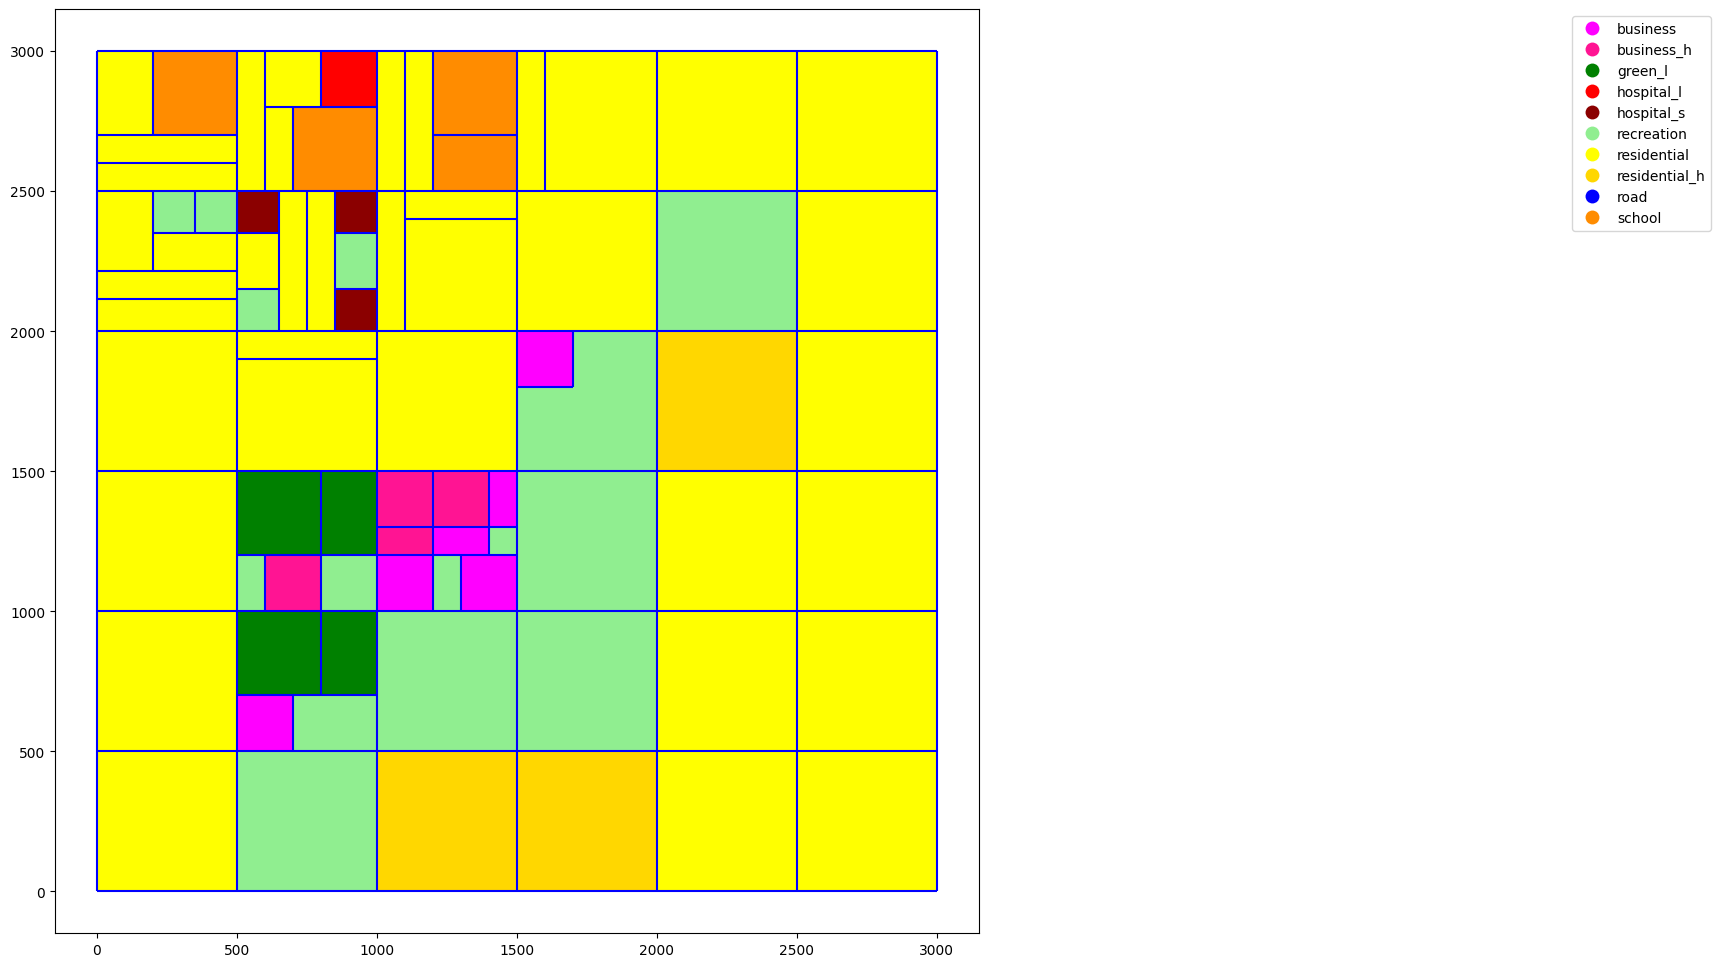

In [43]:
#-0.33
env.visualize()

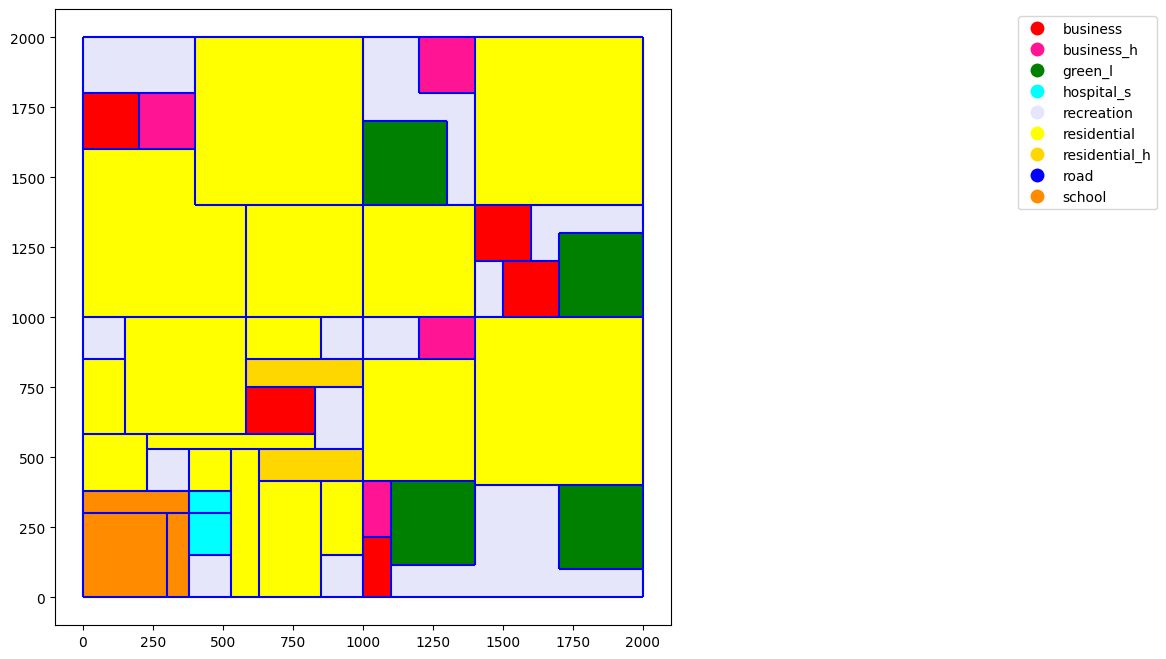

In [ ]:
#4.05
env.visualize()

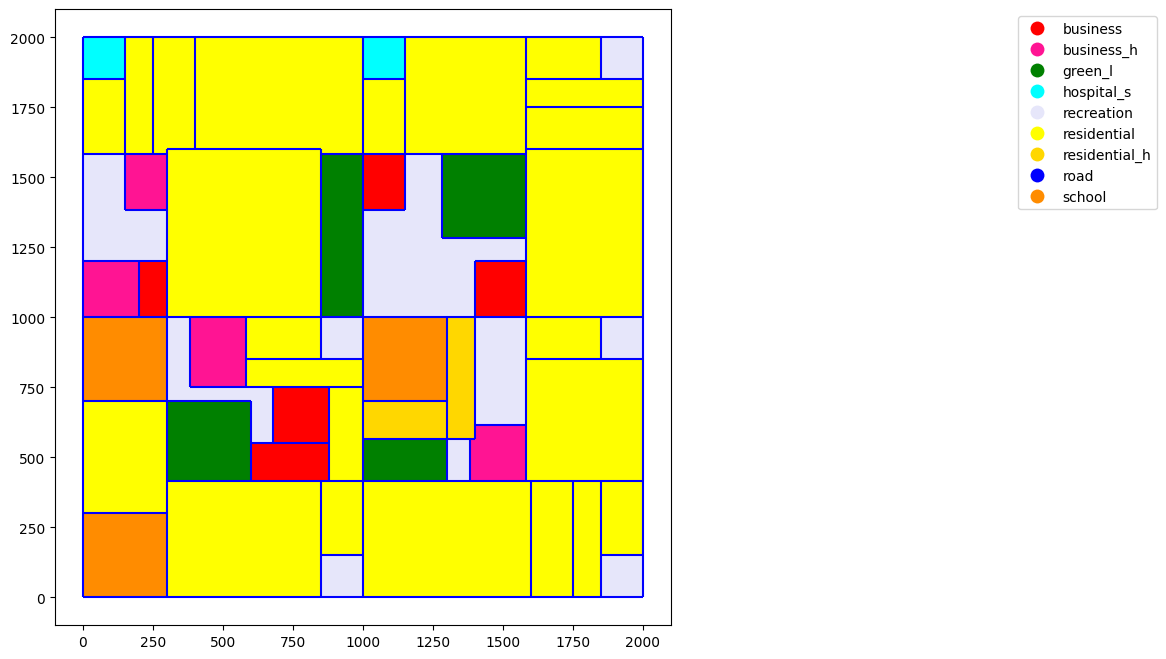

In [ ]:
#3.34
env.visualize()


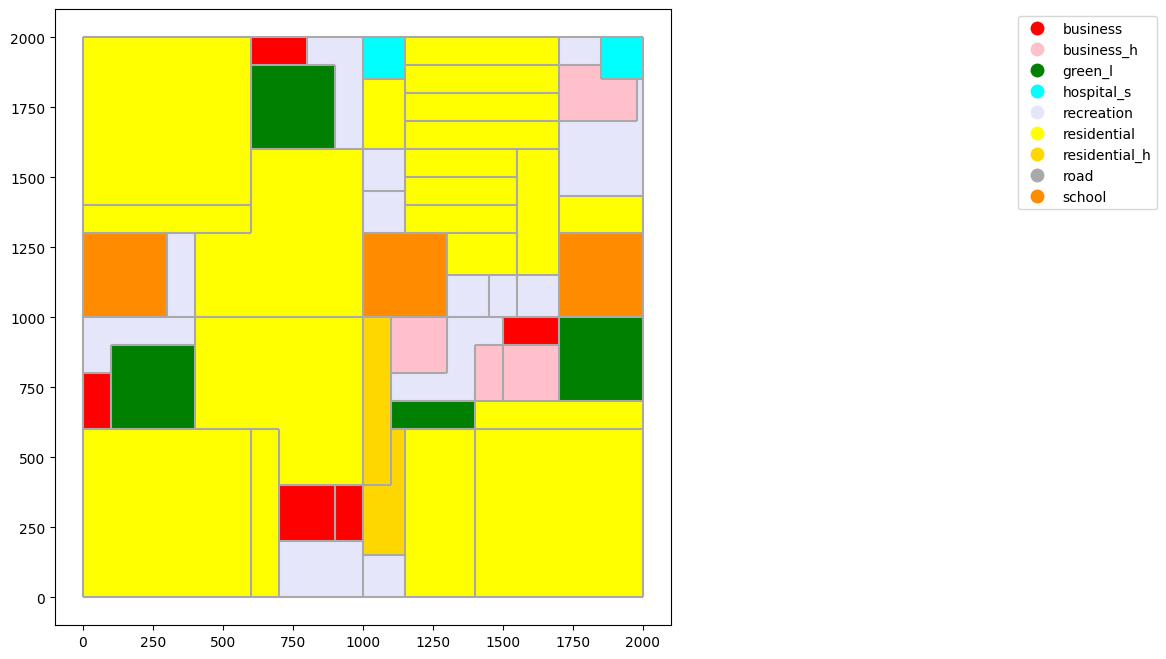

In [ ]:

env.visualize()

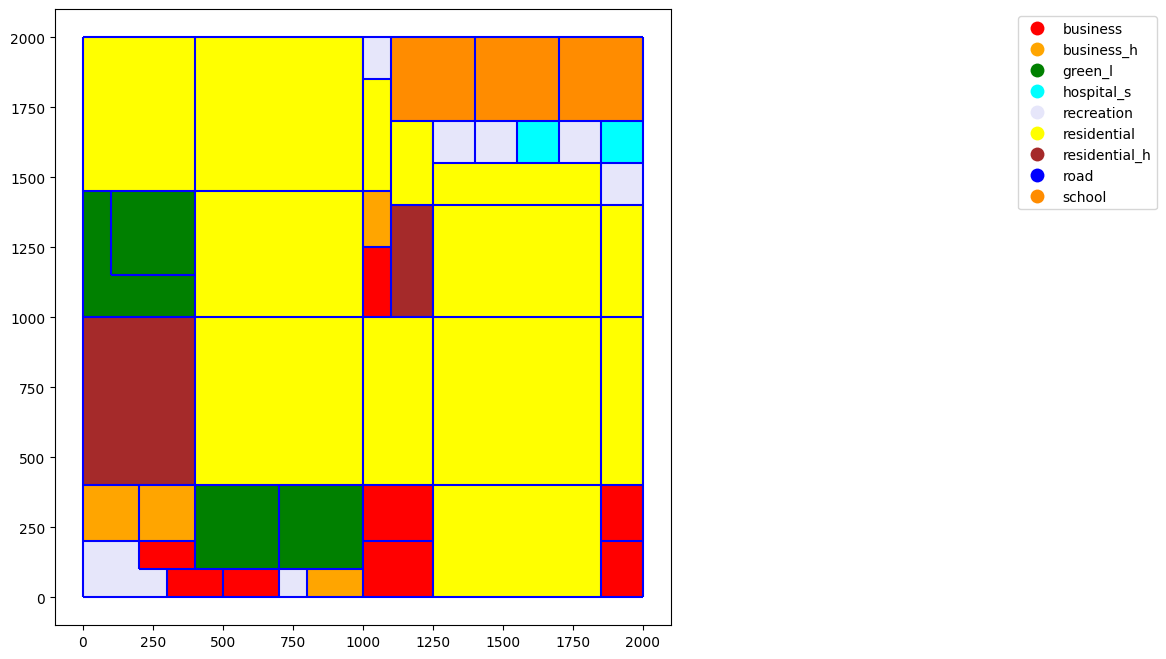

In [ ]:
#import urban_planning.envs.city_config as city_config
env.visualize()

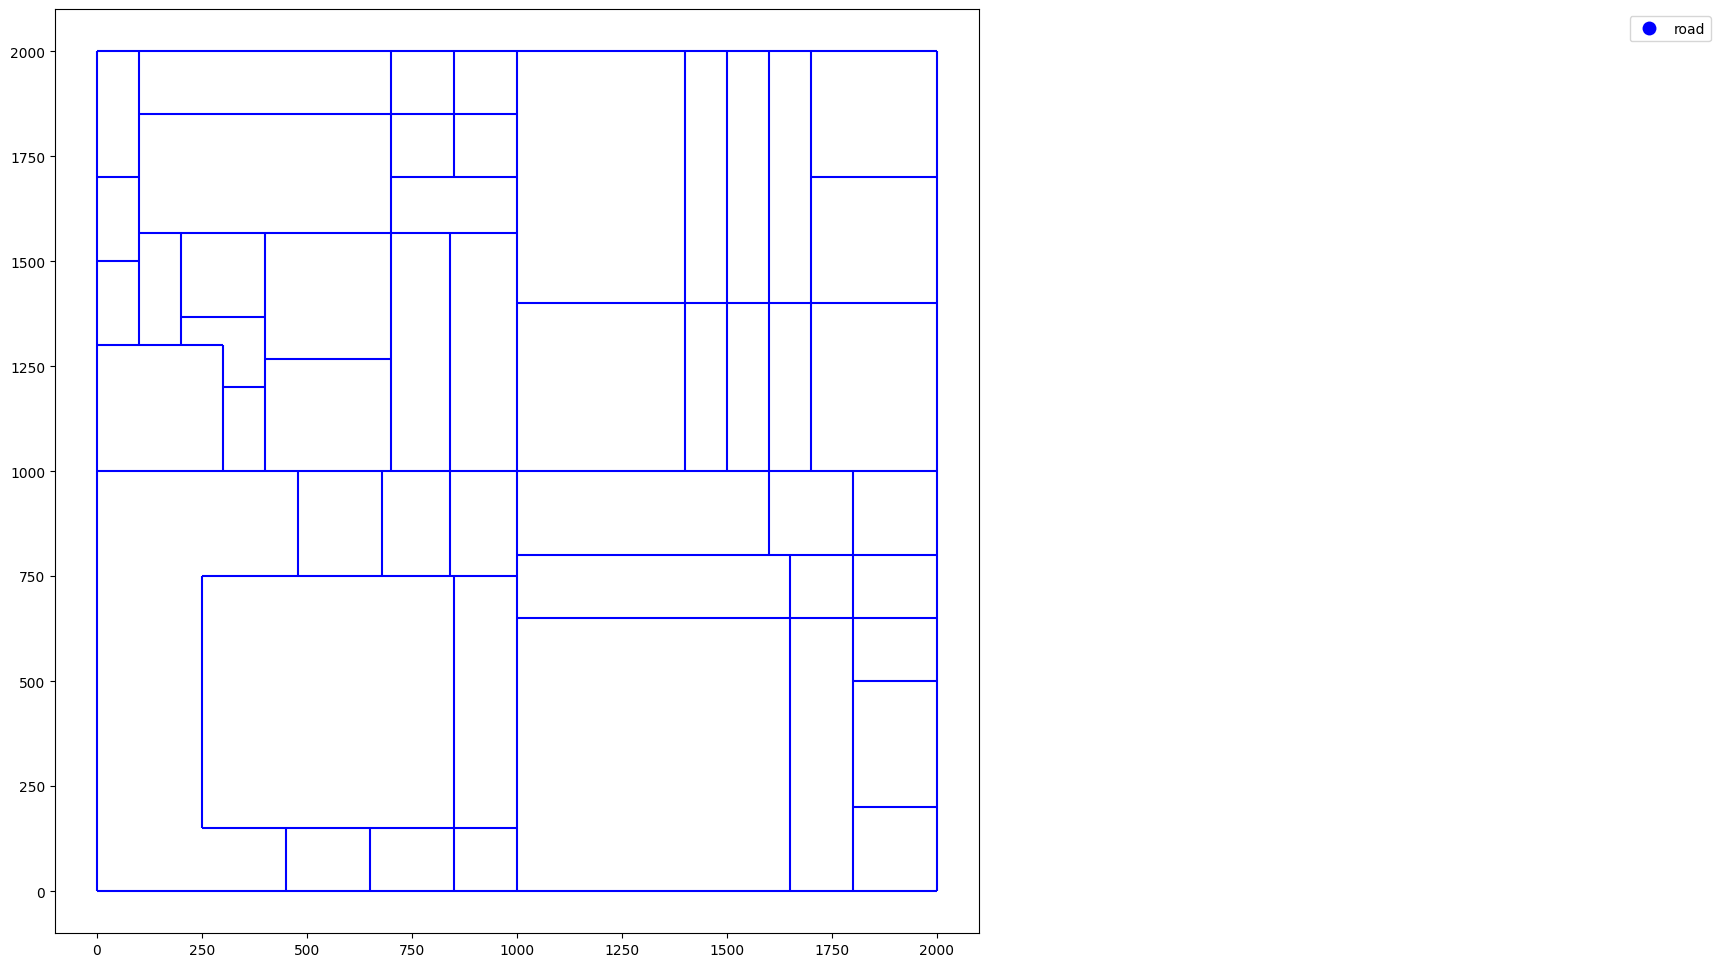

In [12]:
env.visualize_road_and_boundary()

In [ ]:
import geojson

features = []

# 区域尺寸
length = 2000  # 米
width = 2000   # 米
grid_size = 1000  # 米

id_counter = 1

# 生成小正方形的顶点和边
for x in range(0, length, grid_size):
    for y in range(0, width, grid_size):
        # 定义四个顶点坐标
        v1 = [x, y]
        v2 = [x + grid_size, y]
        v3 = [x + grid_size, y + grid_size]
        v4 = [x, y + grid_size]

        # 创建顶点要素，类型为 13
        for vx, vy in [v1, v2, v3, v4]:
            point = geojson.Point([vx, vy])
            feature = geojson.Feature(
                geometry=point,
                properties={
                    "id": id_counter,
                    "type": 13,
                    "existence": True
                }
            )
            features.append(feature)
            id_counter += 1

        # 创建边要素，类型为 2
        edges = [
            [v1, v2],
            [v2, v3],
            [v3, v4],
            [v4, v1]
        ]
        for edge in edges:
            line = geojson.LineString(edge)
            feature = geojson.Feature(
                geometry=line,
                properties={
                    "id": id_counter,
                    "type": 2,
                    "existence": True
                }
            )
            features.append(feature)
            id_counter += 1

        # 可选：创建小正方形的多边形要素（如果需要）
        polygon = geojson.Polygon([[v1, v2, v3, v4, v1]])
        feature = geojson.Feature(
            geometry=polygon,
            properties={
                "id": id_counter,
                "type": 1,  # 多边形类型，可根据需要调整
                "existence": True
            }
        )
        features.append(feature)
        id_counter += 1

# 创建 FeatureCollection
feature_collection = geojson.FeatureCollection(features)

# 保存为 geojson 文件
with open('output.geojson', 'w') as f:
    geojson.dump(feature_collection, f)

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 加载 GeoJSON 文件
gdf = gpd.read_file('output.geojson')

# 查看前几行数据
print(gdf.head())

# 查看数据的概述
#print(gdf.info())



   id  type  existence                                           geometry
0   1    13       True                                POINT (0.000 0.000)
1   2    13       True                             POINT (1000.000 0.000)
2   3    13       True                          POINT (1000.000 1000.000)
3   4    13       True                             POINT (0.000 1000.000)
4   9     1       True  POLYGON ((0.000 0.000, 1000.000 0.000, 1000.00...


In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         25 non-null     int64   
 1   type       25 non-null     int64   
 2   existence  25 non-null     bool    
 3   geometry   25 non-null     geometry
dtypes: bool(1), geometry(1), int64(2)
memory usage: 753.0 bytes


In [ ]:
gdf=gdf.drop_duplicates(subset='geometry')

In [ ]:
from shapely.geometry import Point, LineString

# 生成包含指定记录和LineString的数组
records = [
    {
        'distance': 200,
        'geometry': Point(1000, 1000),
        'land_use': [5, 6],
        'type': 'center'
    },
    {
        'distance': 50,
        'geometry': LineString([(500.0, 1000.0), (1500.0, 1000.0)]),
        'land_use': [12],
        'type': 'axis'
    },
    {
        'distance': 50,
        'geometry': LineString([(1000.0, 500.0), (1000.0, 1500.0)]),
        'land_use': [7, 8],
        'type': 'axis'
    }
]
concept_dict = {'concept': records, 'gdf': gdf}
print(concept_dict)


{'concept': [{'distance': 200, 'geometry': <shapely.geometry.point.Point object at 0x7ff6223faee0>, 'land_use': [5, 6], 'type': 'center'}, {'distance': 50, 'geometry': <shapely.geometry.linestring.LineString object at 0x7ff6223faf10>, 'land_use': [12], 'type': 'axis'}, {'distance': 50, 'geometry': <shapely.geometry.linestring.LineString object at 0x7ff6223faa60>, 'land_use': [7, 8], 'type': 'axis'}], 'gdf':     id  type  existence                                           geometry
0    1    13       True                                POINT (0.000 0.000)
1    2    13       True                             POINT (1000.000 0.000)
2    3    13       True                          POINT (1000.000 1000.000)
3    4    13       True                             POINT (0.000 1000.000)
4    9     1       True  POLYGON ((0.000 0.000, 1000.000 0.000, 1000.00...
5   12    13       True                          POINT (1000.000 2000.000)
6   13    13       True                             POINT (0.000

In [ ]:
with open('./init_plan_grid3_concept.pickle', 'wb') as f:
    pickle.dump(d, f)

In [ ]:
gdf[gdf['type']==13]

,id,type,existence,geometry
0,1,13,True,POINT (0.00000 0.00000)
1,2,13,True,POINT (1000.00000 0.00000)
2,3,13,True,POINT (1000.00000 1000.00000)
3,4,13,True,POINT (0.00000 1000.00000)
11,12,13,True,POINT (1000.00000 2000.00000)
12,13,13,True,POINT (0.00000 2000.00000)
19,20,13,True,POINT (2000.00000 0.00000)
20,21,13,True,POINT (2000.00000 1000.00000)
29,30,13,True,POINT (2000.00000 2000.00000)


In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         25 non-null     int64   
 1   type       25 non-null     int64   
 2   existence  25 non-null     bool    
 3   geometry   25 non-null     geometry
dtypes: bool(1), geometry(1), int64(2)
memory usage: 753.0 bytes


In [ ]:
import geopandas as gpd
from shapely.geometry import LineString
# 定义一个函数来规范化LineString
def normalize_linestring(ls):
    print(ls)
    coords = list(ls.coords)
    if len(coords) < 2:
        raise ValueError("LineStrings must have at least 2 coordinate tuples")
    return LineString(coords) if coords[0] < coords[-1] else LineString(coords[::-1])

# 应用规范化函数
gdf_line=gdf[gdf['type']==2]
gdf_line['normalized_geometry'] = gdf_line['geometry'].apply(normalize_linestring)

# 删除重复的LineString
gdf_line = gdf_line.drop_duplicates(subset='normalized_geometry')

# 删除辅助列
gdf_line = gdf_line.drop(columns='normalized_geometry')

print(gdf_line)

LINESTRING (0 0, 1000 0)
LINESTRING (1000 0, 1000 1000)
LINESTRING (1000 1000, 0 1000)
LINESTRING (0 1000, 0 0)
LINESTRING (0 1000, 1000 1000)
LINESTRING (1000 1000, 1000 2000)
LINESTRING (1000 2000, 0 2000)
LINESTRING (0 2000, 0 1000)
LINESTRING (1000 0, 2000 0)
LINESTRING (2000 0, 2000 1000)
LINESTRING (2000 1000, 1000 1000)
LINESTRING (1000 1000, 1000 0)
LINESTRING (1000 1000, 2000 1000)
LINESTRING (2000 1000, 2000 2000)
LINESTRING (2000 2000, 1000 2000)
LINESTRING (1000 2000, 1000 1000)
    id  type  existence                                           geometry
4    5     2       True   LINESTRING (0.00000 0.00000, 1000.00000 0.00000)
5    6     2       True  LINESTRING (1000.00000 0.00000, 1000.00000 100...
6    7     2       True  LINESTRING (1000.00000 1000.00000, 0.00000 100...
7    8     2       True   LINESTRING (0.00000 1000.00000, 0.00000 0.00000)
14  15     2       True  LINESTRING (1000.00000 1000.00000, 1000.00000 ...
15  16     2       True  LINESTRING (1000.00000 2000.0

/home/lxh/anaconda3/envs/urban3/lib/python3.9/site-packages/geopandas/geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
gdf_line.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 12 entries, 4 to 33
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         12 non-null     int64   
 1   type       12 non-null     int64   
 2   existence  12 non-null     bool    
 3   geometry   12 non-null     geometry
dtypes: bool(1), geometry(1), int64(2)
memory usage: 396.0 bytes


In [ ]:
gdf=gdf[gdf['type']!=2]

In [ ]:
print(gdf)

    id  type  existence                                           geometry
0    1    13       True                                POINT (0.000 0.000)
1    2    13       True                             POINT (1000.000 0.000)
2    3    13       True                          POINT (1000.000 1000.000)
3    4    13       True                             POINT (0.000 1000.000)
4    9     1       True  POLYGON ((0.000 0.000, 1000.000 0.000, 1000.00...
5   12    13       True                          POINT (1000.000 2000.000)
6   13    13       True                             POINT (0.000 2000.000)
7   18     1       True  POLYGON ((0.000 1000.000, 1000.000 1000.000, 1...
8   20    13       True                             POINT (2000.000 0.000)
9   21    13       True                          POINT (2000.000 1000.000)
10  27     1       True  POLYGON ((1000.000 0.000, 2000.000 0.000, 2000...
11  30    13       True                          POINT (2000.000 2000.000)
12  36     1       True  

In [ ]:
gdf.to_file('output_noline.geojson', driver='GeoJSON')

In [ ]:
# 合并 gdf 和 gdf_line
gdf_combined = gpd.GeoDataFrame(gpd.concat([gdf, gdf_line], ignore_index=True))

# 查看合并后的数据
print(gdf_combined)

AttributeError: module 'geopandas' has no attribute 'concat'

In [ ]:
gdf_line.to_file('output_line.geojson', driver='GeoJSON')

In [ ]:
def plot_gdf(gdf, filename=None, **kwargs):
    fig, ax = plt.subplots(1, 1, figsize=(3,2))
    
    gdf[gdf.geometry.type == 'Polygon'].plot(ax=ax, color='gray', edgecolor='black')

    gdf[gdf.geometry.type == 'LineString'].plot(ax=ax, color='red')
    gdf.plot(ax=ax, linewidth=1, markersize=2 , **kwargs)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.set_aspect('equal')
    if filename is not None:
        plt.savefig(filename)
    plt.show()

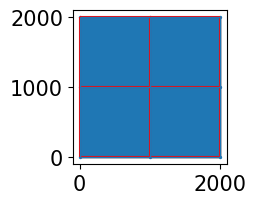

In [ ]:
# 可视化地理数据
plot_gdf(gdf)
plt.show()

In [ ]:
gdf.to_file('init_grid3_200.geojson', driver='GeoJSON')

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 加载 GeoJSON 文件
gdf = gpd.read_file('init_grid3_200.geojson')

ValueError: aspect must be finite and positive 

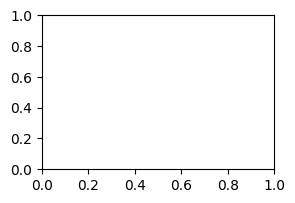

In [ ]:
plot_gdf(gdf)

In [ ]:
d=dict()
d['gdf'] = gdf
with open('./init_plan_grid3.pickle', 'wb') as f:
    pickle.dump(d, f)

In [ ]:
concept_d= pickle.load(open('init_plan_grid3_concept.pickle', 'rb'))

In [ ]:
concept_d

{'actor_critic_dict': OrderedDict([('actor_net.shared_net.numerical_feature_encoder.linear_0.weight',
               tensor([[ 0.0598,  0.1148, -0.0605,  ..., -0.1350, -0.0367,  0.1326],
                       [ 0.0991, -0.0837, -0.1313,  ..., -0.0392, -0.0180, -0.0117],
                       [ 0.0684,  0.0856,  0.0341,  ..., -0.1309, -0.0149,  0.0606],
                       ...,
                       [ 0.0821, -0.0509,  0.0314,  ...,  0.0580,  0.0497, -0.0999],
                       [ 0.0814,  0.0069, -0.0475,  ...,  0.1037,  0.0594,  0.0390],
                       [-0.0442,  0.0662, -0.0022,  ...,  0.1352, -0.0164,  0.0367]])),
              ('actor_net.shared_net.numerical_feature_encoder.linear_0.bias',
               tensor([-0.0333,  0.0622,  0.0468, -0.0264,  0.1025,  0.0855, -0.1292, -0.1473,
                       -0.0217, -0.1401,  0.0456, -0.0037,  0.0614, -0.0249, -0.1400,  0.0558,
                        0.0729, -0.1343, -0.0322,  0.0251, -0.0754, -0.0971,  0.0754,  0

In [ ]:
gdf= d['gdf']

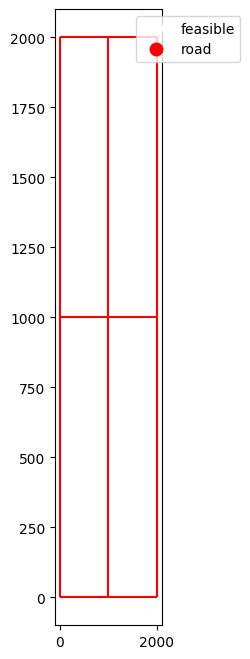

In [ ]:
env.load_plan(gdf)
env.visualize()